### Human In the Loop
Review
For human-in-the-loop, we often want to see our graph outputs as its running.

We laid the foundations for this with streaming.

Goals
Now, let's talk about the motivations for human-in-the-loop:

(1) Approval - We can interrupt our agent, surface state to a user, and allow the user to accept an action

(2) Debugging - We can rewind the graph to reproduce or avoid issues

(3) Editing - You can modify the state

LangGraph offers several ways to get or update agent state to support various human-in-the-loop workflows.

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

from langchain_groq import ChatGroq


#os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

llm = ChatGroq(
    model="openai/gpt-oss-120b",
)
#llm = ChatOpenAI(model="gpt-4o")
result=llm.invoke("Hello")
result

AIMessage(content='Hello! How can I help you today?', additional_kwargs={'reasoning_content': 'The user says "Hello". We should respond politely. There\'s no disallowed content. Just greet.'}, response_metadata={'token_usage': {'completion_tokens': 39, 'prompt_tokens': 72, 'total_tokens': 111, 'completion_time': 0.082064005, 'completion_tokens_details': {'reasoning_tokens': 21}, 'prompt_time': 0.003601786, 'prompt_tokens_details': None, 'queue_time': 0.396400121, 'total_time': 0.085665791}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_19b184c447', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0c818-d498-7c63-86bc-27981bc36492-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 72, 'output_tokens': 39, 'total_tokens': 111, 'output_token_details': {'reasoning': 21}})

In [3]:
 ### Custom Tools 

def Multiply(a: int , b: int):
    """
        Multiply A and B

        Args :
            a: first int
            b: second int 
    """

    return a * b 

def Addition(a: int , b: int):
    """
        Add A and B

        Args :
            a: first int
            b: second int 
    """

    return a + b 

def Division(a: int , b: int):
    """
        Divide A and B

        Args :
            a: first int
            b: second int 
    """

    return a / b 

tools = [Multiply , Addition , Division]
tools

[<function __main__.Multiply(a: int, b: int)>,
 <function __main__.Addition(a: int, b: int)>,
 <function __main__.Division(a: int, b: int)>]

In [7]:
### Integrate Custom Tools With LLms 

# Use bind_tools instead of bind
llm_with_tools = llm.bind_tools(tools)
llm_with_tools


_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.2', 'langchain': '1.4.0'}}, profile={'name': 'GPT OSS 120B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x00000239154FBBF0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000023915B53650>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'Multiply', 'description': 'Multiply A and B Args :\n    a: first int\n    b: second int',

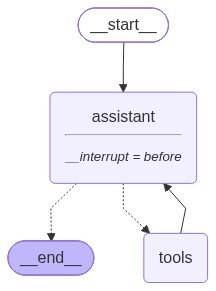

In [8]:
### WWorkflow with Langgraph
from IPython.display import Image, display

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import MessagesState
from langgraph.graph import START, StateGraph
from langgraph.prebuilt import tools_condition, ToolNode
from langchain_core.messages import AIMessage,HumanMessage,SystemMessage

## system Message
sys_msg = SystemMessage(content="You are a helpful assistant tasked with performing arithmetic on a set of inputs.")

## node definition
def assistant(state:MessagesState):
    return {"messages":[llm_with_tools.invoke([sys_msg] + state["messages"])]}

#Graph
builder=StateGraph(MessagesState)

## Define nodes: 
builder.add_node("assistant",assistant)
builder.add_node("tools",ToolNode(tools))

## Define the Edges

builder.add_edge(START,"assistant")
builder.add_conditional_edges(
    "assistant",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,

)
builder.add_edge("tools","assistant")

memory=MemorySaver()

### human in the loop
graph=builder.compile(interrupt_before=["assistant"],checkpointer=memory)

# Show
display(Image(graph.get_graph().draw_mermaid_png()))






In [9]:
thread={"configurable":{"thread_id":"123"}}
initial_input={"messages":HumanMessage(content="Multiply 2 and 3")}

In [10]:
for event in graph.stream(initial_input,thread,stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3


In [13]:
state=graph.get_state(thread)
state.next

('assistant',)

In [14]:
graph.get_state_history(thread)

<generator object Pregel.get_state_history at 0x00000239176F1E80>

In [15]:
state

StateSnapshot(values={'messages': [HumanMessage(content='Multiply 2 and 3', additional_kwargs={}, response_metadata={}, id='71432d45-0a82-4f0b-ae87-22566b56f816')]}, next=('assistant',), config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f1b65c4-b1c5-6682-8000-3d69f33dd12a'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-09-22T08:04:53.859085+00:00', parent_config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f1b65c4-b1c1-6bb3-bfff-05724acf3088'}}, tasks=(PregelTask(id='f7b714f0-b3e0-0fa7-12c4-e62944c9d180', name='assistant', path=('__pregel_pull', 'assistant'), error=None, interrupts=(), state=None, result=None),), interrupts=())

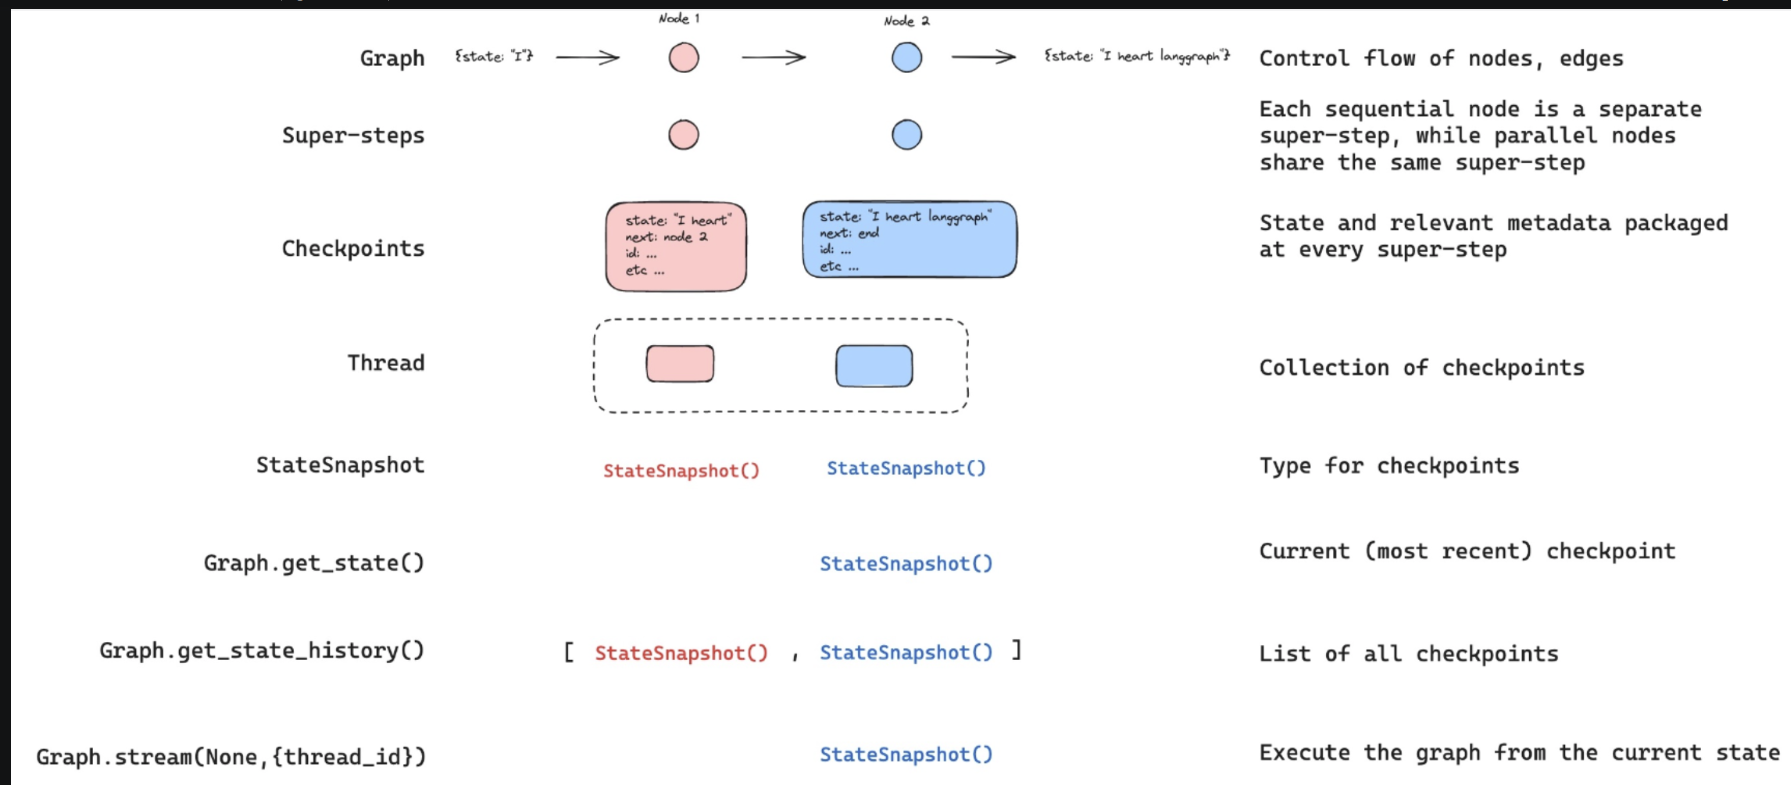

In [16]:
## Continue the execution to Assistant
for event in graph.stream(None,thread,stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================== Ai Message ==================================
Tool Calls:
  Multiply (fc_ab9e49e7-7477-471d-8182-4c0cb9c15359)
 Call ID: fc_ab9e49e7-7477-471d-8182-4c0cb9c15359
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: Multiply

6


### Edit Human Feedback

In [17]:
initial_input={"messages":HumanMessage(content="Multiply 2 and 3")}

thread={"configurable":{"thread_id":"1"}}
for event in graph.stream(initial_input,thread,stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3


In [18]:
state=graph.get_state(thread)
state.next

('assistant',)

In [19]:
graph.update_state(thread,{"messages":[HumanMessage(content="No,please multiply 15 and 6")]})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f1b6869-5e0e-6ee8-8001-76eafddb42dc'}}

In [20]:
new_state=graph.get_state(thread).values

for m in new_state['messages']:
    m.pretty_print()


================================ Human Message =================================

Multiply 2 and 3
================================ Human Message =================================

No,please multiply 15 and 6


In [21]:
for event in graph.stream(None, thread, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

No,please multiply 15 and 6
================================== Ai Message ==================================
Tool Calls:
  Multiply (fc_603f1b32-44fe-4297-9d5a-49ccdb34a23e)
 Call ID: fc_603f1b32-44fe-4297-9d5a-49ccdb34a23e
  Args:
    a: 15
    b: 6
================================= Tool Message =================================
Name: Multiply

90


In [22]:
for event in graph.stream(None, thread, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================= Tool Message =================================
Name: Multiply

90
================================== Ai Message ==================================

The product of 15 and 6 is **90**.


### Workflow will Wait for the User Input

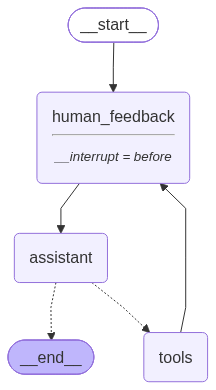

In [23]:
# System message
sys_msg = SystemMessage(content="You are a helpful assistant tasked with performing arithmetic on a set of inputs.")


## Human feedback node

def human_feedback(state:MessagesState):
    pass

### Assistant node
def assistant(state:MessagesState):
    return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])]}

## Graph

# Graph
builder = StateGraph(MessagesState)

# Define nodes: these do the work
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))
builder.add_node("human_feedback", human_feedback)


## Define the edges
builder.add_edge(START,"human_feedback")
builder.add_edge("human_feedback","assistant")
builder.add_conditional_edges(
    "assistant",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools","human_feedback")

memory=MemorySaver()
graph=builder.compile(interrupt_before=["human_feedback"],checkpointer=memory)

display(Image(graph.get_graph().draw_mermaid_png()))


In [24]:
# Input
initial_input = {"messages": "Multiply 2 and 3"}

# Thread
thread = {"configurable": {"thread_id": "5"}}

# Run the graph until the first interruption
for event in graph.stream(initial_input, thread, stream_mode="values"):
    event["messages"][-1].pretty_print()

## get user input

user_input=input("Tell me how you want to update the state:")
graph.update_state(thread,{"messages":user_input},as_node="human_feedback")

# Continue the graph execution
for event in graph.stream(None, thread, stream_mode="values"):
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================ Human Message =================================

add 2 and 5
================================== Ai Message ==================================
Tool Calls:
  Multiply (fc_7899102f-3d11-4636-a53d-2567c343993a)
 Call ID: fc_7899102f-3d11-4636-a53d-2567c343993a
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: Multiply

6


In [25]:
# Continue the graph execution
for event in graph.stream(None, thread, stream_mode="values"):
    event["messages"][-1].pretty_print()

================================= Tool Message =================================
Name: Multiply

6
================================== Ai Message ==================================
Tool Calls:
  Addition (fc_24aa790a-a4cc-4d02-9987-7feb30e837cc)
 Call ID: fc_24aa790a-a4cc-4d02-9987-7feb30e837cc
  Args:
    a: 2
    b: 5
================================= Tool Message =================================
Name: Addition

7
